# Proceso ETL: Extracción, Transformación y Carga

## 1. Extracción de Datos (Extract)

In [1]:
import pandas as pd
import requests
df = pd.read_csv('dataset_car_seats.csv')

In [2]:
# Definimos la URL de la API
api_url = 'https://mindicador.cl/api'

api_params = {}
response = requests.get(api_url, params=api_params)
response.raise_for_status() # Lanza un error si la solicitud HTTP no fue exitosa

api_data = response.json()

indicator_list = []
for key, value in api_data.items():
    # Ignorar metadatos de la API y solo procesar los indicadores reales
    if isinstance(value, dict) and 'valor' in value:
        indicator_data = {'indicador': key}
        indicator_data.update(value)
        indicator_list.append(indicator_data)

df_api = pd.DataFrame(indicator_list)

print(f"Datos de la API obtenidos: {len(df_api)} registros.")
display(df_api.head())

valor_dolar = float(api_data['dolar']['valor'])
print(f"\nEl valor actual del dólar obtenido para la transformación es: ${valor_dolar} CLP")

Datos de la API obtenidos: 12 registros.


,indicador,codigo,nombre,unidad_medida,fecha,valor
0,uf,uf,Unidad de fomento (UF),Pesos,2026-07-05T04:00:00.000Z,40833.91
1,ivp,ivp,Indice de valor promedio (IVP),Pesos,2026-07-05T04:00:00.000Z,42027.83
2,dolar,dolar,Dólar observado,Pesos,2026-07-03T04:00:00.000Z,921.70
3,dolar_intercambio,dolar_intercambio,Dólar acuerdo,Pesos,2014-11-13T03:00:00.000Z,758.87
4,euro,euro,Euro,Pesos,2026-07-03T04:00:00.000Z,1053.85



El valor actual del dólar obtenido para la transformación es: $921.7 CLP


## 2. Transformación de Datos (Transform)

In [3]:
# Inspeccionar y limpiar el DataFrame CSV
df.info()
df = df.drop(columns=['Unnamed: 0'])

print("\nValores nulos en df antes de la limpieza:")
display(df.isnull().sum())

# Manejar valores nulos
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            mean_val = df[col].mean()
            df[col].fillna(mean_val, inplace=True)
            print(f"Columna '{col}': nulos rellenados con la media ({mean_val:.2f}).")
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Columna '{col}': nulos rellenados con el modo ('{mode_val}').")

# Convertir a tipo categórico para eficiencia de memoria
for col in ['ShelveLoc', 'Urban', 'US']:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"Columna '{col}' convertida a tipo categórico.")

print("\nConvirtiendo Columnas Monetarias de USD a CLP")
columnas_monetarias = ['CompPrice', 'Income', 'Advertising', 'Price']

for col in columnas_monetarias:
    df[col] = df[col] * valor_dolar
    print(f"Columna '{col}' convertida exitosamente a pesos chilenos.")

df['HighSales'] = df['Sales'].apply(lambda x: 1 if x > 8 else 0)
print('Variable "HighSales" creada.')

print("\nValores nulos en df después de la limpieza:")
display(df.isnull().sum())
print("Información final de df después de la transformación:")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   400 non-null    int64  
 1   Sales        400 non-null    float64
 2   CompPrice    400 non-null    int64  
 3   Income       400 non-null    int64  
 4   Advertising  400 non-null    int64  
 5   Population   400 non-null    int64  
 6   Price        400 non-null    int64  
 7   ShelveLoc    400 non-null    object 
 8   Age          400 non-null    int64  
 9   Education    400 non-null    int64  
 10  Urban        400 non-null    object 
 11  US           400 non-null    object 
dtypes: float64(1), int64(8), object(3)
memory usage: 37.6+ KB

Valores nulos en df antes de la limpieza:


,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0


Columna 'ShelveLoc' convertida a tipo categórico.
Columna 'Urban' convertida a tipo categórico.
Columna 'US' convertida a tipo categórico.

Convirtiendo Columnas Monetarias de USD a CLP
Columna 'CompPrice' convertida exitosamente a pesos chilenos.
Columna 'Income' convertida exitosamente a pesos chilenos.
Columna 'Advertising' convertida exitosamente a pesos chilenos.
Columna 'Price' convertida exitosamente a pesos chilenos.
Variable "HighSales" creada.

Valores nulos en df después de la limpieza:


,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0


Información final de df después de la transformación:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Sales        400 non-null    float64 
 1   CompPrice    400 non-null    float64 
 2   Income       400 non-null    float64 
 3   Advertising  400 non-null    float64 
 4   Population   400 non-null    int64   
 5   Price        400 non-null    float64 
 6   ShelveLoc    400 non-null    category
 7   Age          400 non-null    int64   
 8   Education    400 non-null    int64   
 9   Urban        400 non-null    category
 10  US           400 non-null    category
 11  HighSales    400 non-null    int64   
dtypes: category(3), float64(5), int64(4)
memory usage: 29.8 KB


In [4]:
if not df_api.empty:
    # Inspeccionar y limpiar el DataFrame de la API
    print("Información inicial de df_api:")
    df_api.info()
    print("\nValores nulos en df_api antes de la limpieza:")
    display(df_api.isnull().sum())

    # Convertir 'fecha' a tipo datetime
    if 'fecha' in df_api.columns:
        df_api['fecha'] = pd.to_datetime(df_api['fecha'], errors='coerce')
        print("Columna 'fecha' convertida a tipo datetime.")

    # Asegurar que 'valor' sea numérico
    if 'valor' in df_api.columns:
        df_api['valor'] = pd.to_numeric(df_api['valor'], errors='coerce')
        print("Columna 'valor' convertida a tipo numérico.")
        # Rellenar nulos en 'valor' con la media si los hay
        if df_api['valor'].isnull().any():
            df_api['valor'].fillna(df_api['valor'].mean(), inplace=True)
            print("Valores nulos en 'valor' rellenados con la media.")

    # Eliminar columna 'codigo'
    if 'codigo' in df_api.columns:
        df_api.drop(columns=['codigo'], inplace=True)
        print("Columna 'codigo' eliminada.")

    print("\nValores nulos en df_api después de la limpieza:")
    display(df_api.isnull().sum())
    print("Información final de df_api después de la transformación:")
    df_api.info()
else:
    print("El DataFrame de la API está vacío, omitiendo la transformación de la API.")

Información inicial de df_api:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   indicador      12 non-null     object 
 1   codigo         12 non-null     object 
 2   nombre         12 non-null     object 
 3   unidad_medida  12 non-null     object 
 4   fecha          12 non-null     object 
 5   valor          12 non-null     float64
dtypes: float64(1), object(5)
memory usage: 708.0+ bytes

Valores nulos en df_api antes de la limpieza:


,0
indicador,0
codigo,0
nombre,0
unidad_medida,0
fecha,0
valor,0


Columna 'fecha' convertida a tipo datetime.
Columna 'valor' convertida a tipo numérico.
Columna 'codigo' eliminada.

Valores nulos en df_api después de la limpieza:


,0
indicador,0
nombre,0
unidad_medida,0
fecha,0
valor,0


Información final de df_api después de la transformación:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   indicador      12 non-null     object             
 1   nombre         12 non-null     object             
 2   unidad_medida  12 non-null     object             
 3   fecha          12 non-null     datetime64[ns, UTC]
 4   valor          12 non-null     float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(3)
memory usage: 612.0+ bytes


In [5]:
print("\n--- Combinación de Datos (Merge/Join) ---")

# Considerando 'df' como el DataFrame transformado final para la carga.
df_final = df.copy()
print("Considerando 'df' transformado como el DataFrame final para la carga.")


--- Combinación de Datos (Merge/Join) ---
Considerando 'df' transformado como el DataFrame final para la carga.


## 3. Carga de Datos (Load)

In [6]:
# Cargar el DataFrame CSV transformado a un nuevo archivo CSV
output_csv_path_csv = 'transformed_car_seats_data.csv'
df_final.to_csv(output_csv_path_csv, index=False)
print(f"Datos transformados del CSV cargados exitosamente en '{output_csv_path_csv}'.")

# Cargar el DataFrame de la API transformado a un nuevo archivo CSV
if not df_api.empty:
    output_csv_path_api = 'transformed_api_data.csv'
    df_api.to_csv(output_csv_path_api, index=False)
    print(f"Datos transformados de la API cargados exitosamente en '{output_csv_path_api}'.")
else:
    print("El DataFrame de la API está vacío, no se guardará ningún archivo CSV para la API.")

# Mostrar las primeras 10 filas del DataFrame final (CSV) para verificación
print("\nPrimeras 10 filas del DataFrame final (df_final) listo para la carga:")
display(df_final.head(10))

# Mostrar las primeras 10 filas del DataFrame de la API (df_api) para verificación
if not df_api.empty:
    print("\nPrimeras 10 filas del DataFrame de la API (df_api) listo para la carga:")
    display(df_api.head(10))

print("\nProceso ETL completado con éxito (Extracción, Transformación y Carga). Todos los DataFrames procesados se han guardado en archivos CSV separados.")

Datos transformados del CSV cargados exitosamente en 'transformed_car_seats_data.csv'.
Datos transformados de la API cargados exitosamente en 'transformed_api_data.csv'.

Primeras 10 filas del DataFrame final (df_final) listo para la carga:


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,HighSales
0,9.50,127194.6,67284.1,10138.7,276,110604.0,Bad,42,17,Yes,Yes,1
1,11.22,102308.7,44241.6,14747.2,260,76501.1,Good,65,10,Yes,Yes,1
2,10.06,104152.1,32259.5,9217.0,269,73736.0,Medium,59,12,Yes,Yes,1
3,7.40,107838.9,92170.0,3686.8,466,89404.9,Medium,55,14,Yes,Yes,0
4,4.15,129959.7,58988.8,2765.1,340,117977.6,Bad,38,13,Yes,No,0
5,10.81,114290.8,104152.1,11982.1,501,66362.4,Bad,78,16,No,Yes,1
6,6.63,105995.5,96778.5,0.0,45,99543.6,Medium,71,15,Yes,No,0
7,11.85,125351.2,74657.7,13825.5,425,110604.0,Good,67,10,Yes,Yes,1
8,6.54,121664.4,101387.0,0.0,108,114290.8,Medium,76,10,No,No,0
9,4.69,121664.4,104152.1,0.0,131,114290.8,Medium,76,17,No,Yes,0



Primeras 10 filas del DataFrame de la API (df_api) listo para la carga:


,indicador,nombre,unidad_medida,fecha,valor
0,uf,Unidad de fomento (UF),Pesos,2026-07-05 04:00:00+00:00,40833.91
1,ivp,Indice de valor promedio (IVP),Pesos,2026-07-05 04:00:00+00:00,42027.83
2,dolar,Dólar observado,Pesos,2026-07-03 04:00:00+00:00,921.70
3,dolar_intercambio,Dólar acuerdo,Pesos,2014-11-13 03:00:00+00:00,758.87
4,euro,Euro,Pesos,2026-07-03 04:00:00+00:00,1053.85
5,ipc,Indice de Precios al Consumidor (IPC),Porcentaje,2025-12-01 03:00:00+00:00,-0.20
6,utm,Unidad Tributaria Mensual (UTM),Pesos,2026-07-01 04:00:00+00:00,71649.00
7,imacec,Imacec,Porcentaje,2026-05-01 04:00:00+00:00,-0.90
8,tpm,Tasa Política Monetaria (TPM),Porcentaje,2026-07-03 04:00:00+00:00,4.50
9,libra_cobre,Libra de Cobre,Dólar,2026-07-03 04:00:00+00:00,6.01



Proceso ETL completado con éxito (Extracción, Transformación y Carga). Todos los DataFrames procesados se han guardado en archivos CSV separados.


## 4. Análisis Exploratorio de Datos (EDA)

### EDA para `df_final` (Datos de Asientos de Coche)


--- Estadísticas Descriptivas de df_final ---


,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,HighSales
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,115189.457500,63281.617750,6115.479500,264.840000,106728.251500,53.322500,13.900000,0.410000
std,2.824115,14133.819254,25794.729848,6129.640639,147.376436,21822.781558,16.200297,2.620528,0.492449
min,0.000000,70970.900000,19355.700000,0.000000,10.000000,22120.800000,25.000000,10.000000,0.000000
25%,5.390000,105995.500000,39402.675000,0.000000,139.000000,92170.000000,39.750000,12.000000,0.000000
50%,7.490000,115212.500000,63597.300000,4608.500000,272.000000,107838.900000,54.500000,14.000000,0.000000
75%,9.320000,124429.500000,83874.700000,11060.400000,398.500000,120742.700000,66.000000,16.000000,1.000000
max,16.270000,161297.500000,110604.000000,26729.300000,509.000000,176044.700000,80.000000,18.000000,1.000000



--- Distribución de Variables Numéricas en df_final ---


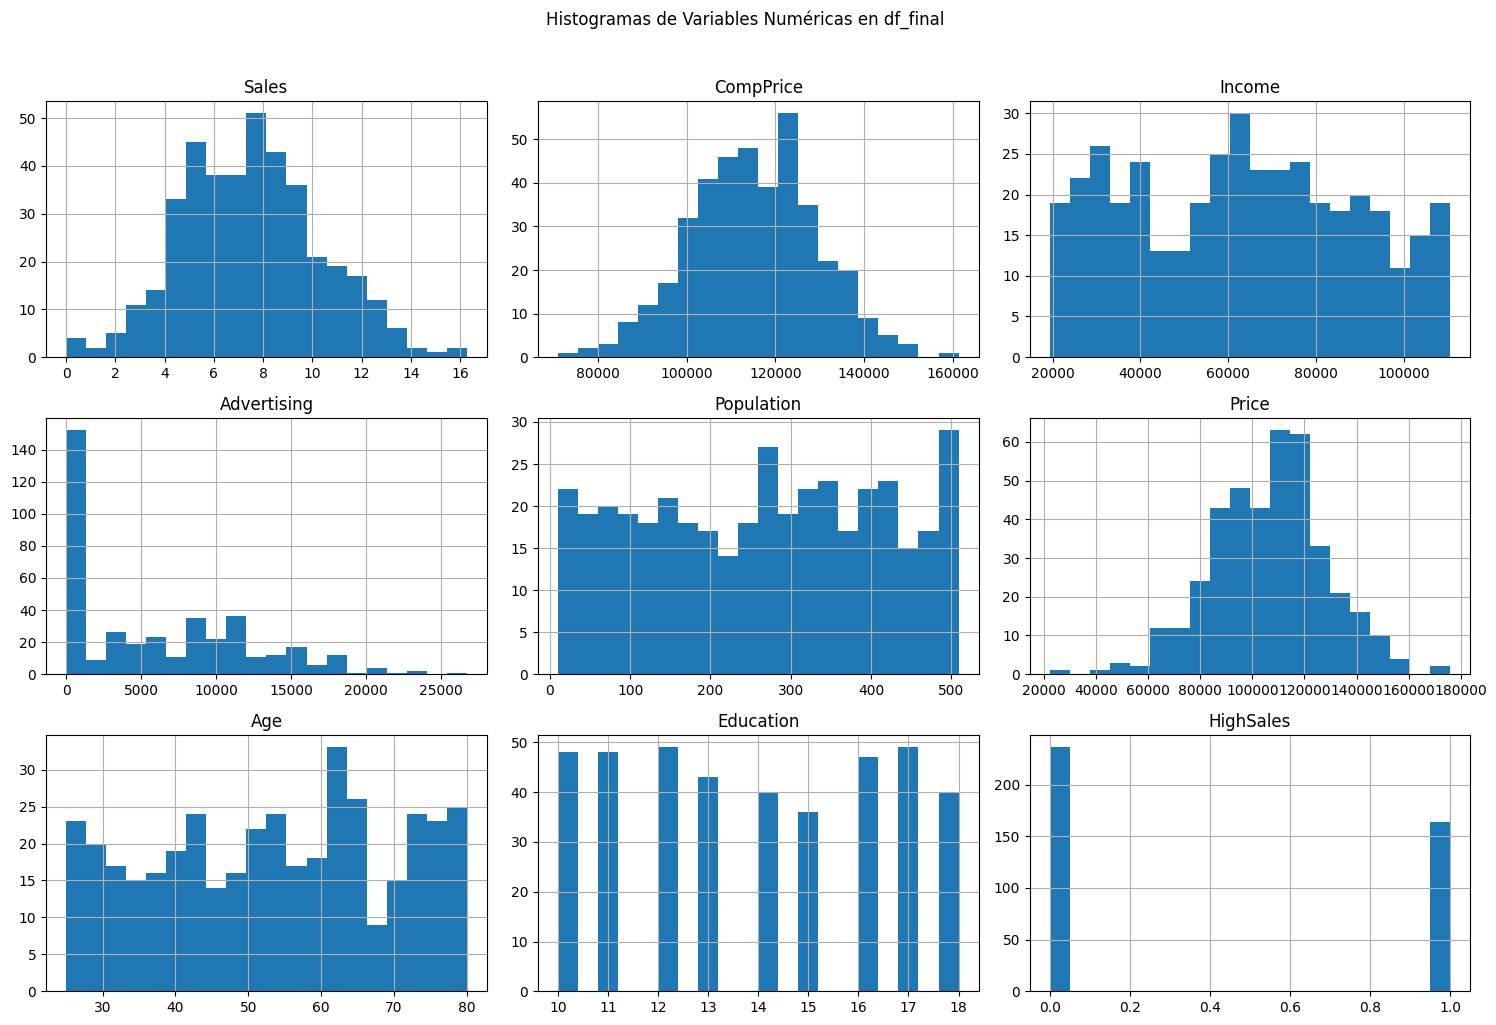

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Estadísticas Descriptivas de df_final ---")
display(df_final.describe())

print("\n--- Distribución de Variables Numéricas en df_final ---")
df_final.hist(figsize=(15, 10), bins=20)
plt.suptitle('Histogramas de Variables Numéricas en df_final', y=1.02)
plt.tight_layout()
plt.show()


--- Distribución de Variables Categóricas en df_final ---


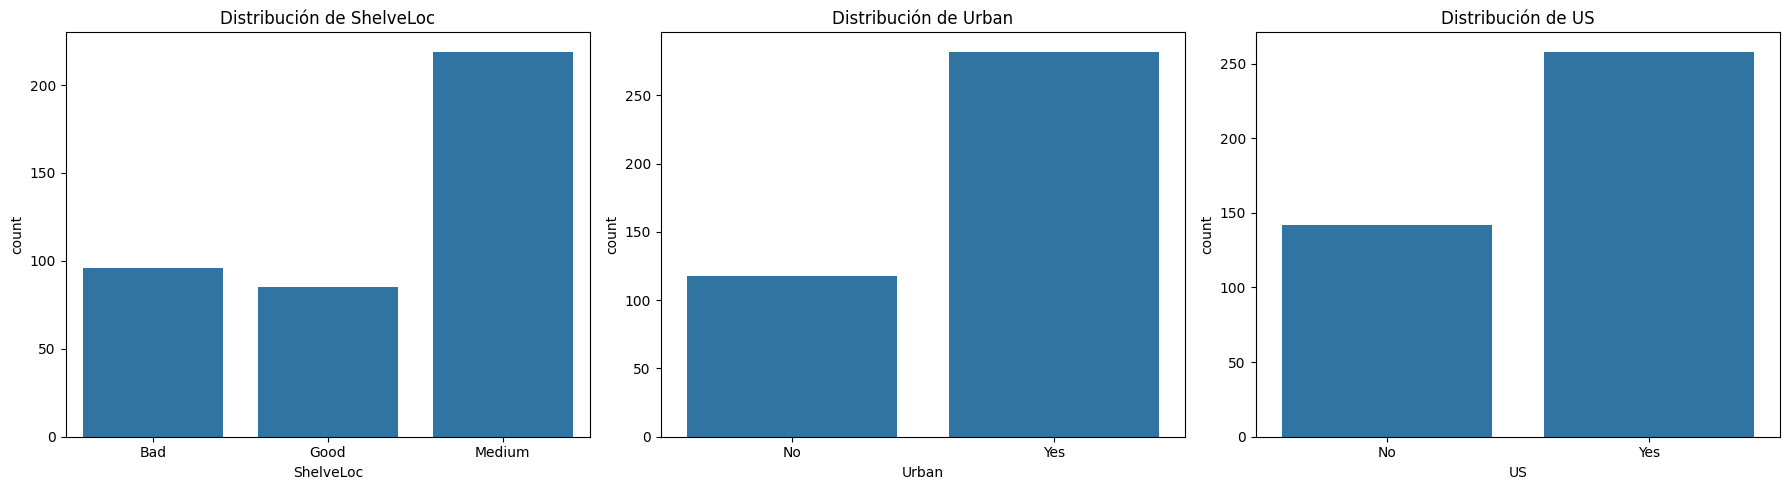

In [8]:
print("\n--- Distribución de Variables Categóricas en df_final ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='ShelveLoc', data=df_final, ax=axes[0])
axes[0].set_title('Distribución de ShelveLoc')
sns.countplot(x='Urban', data=df_final, ax=axes[1])
axes[1].set_title('Distribución de Urban')
sns.countplot(x='US', data=df_final, ax=axes[2])
axes[2].set_title('Distribución de US')
plt.tight_layout()
plt.show()


--- Matriz de Correlación de df_final ---


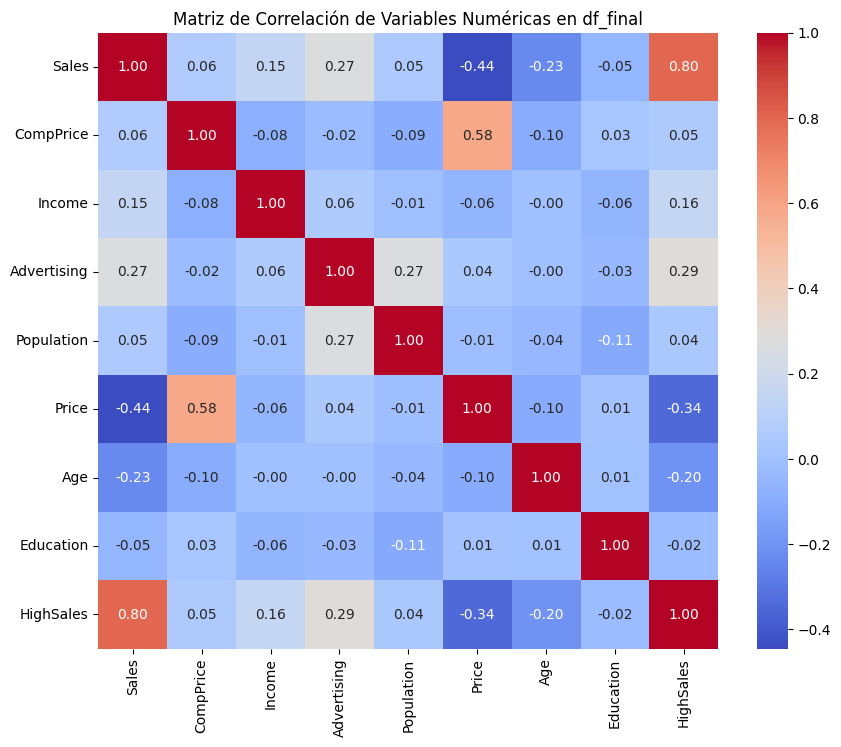

In [9]:
print("\n--- Matriz de Correlación de df_final ---")
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas en df_final')
plt.show()

### EDA para `df_api` (Datos de Indicadores Financieros)


--- Estadísticas Descriptivas de df_api (columna 'valor') ---


,valor
count,12.000000
mean,18362.538333
std,27803.806913
min,-0.900000
25%,5.632500
50%,840.285000
75%,41132.390000
max,71649.000000



--- Evolución temporal de los valores de los indicadores en df_api ---


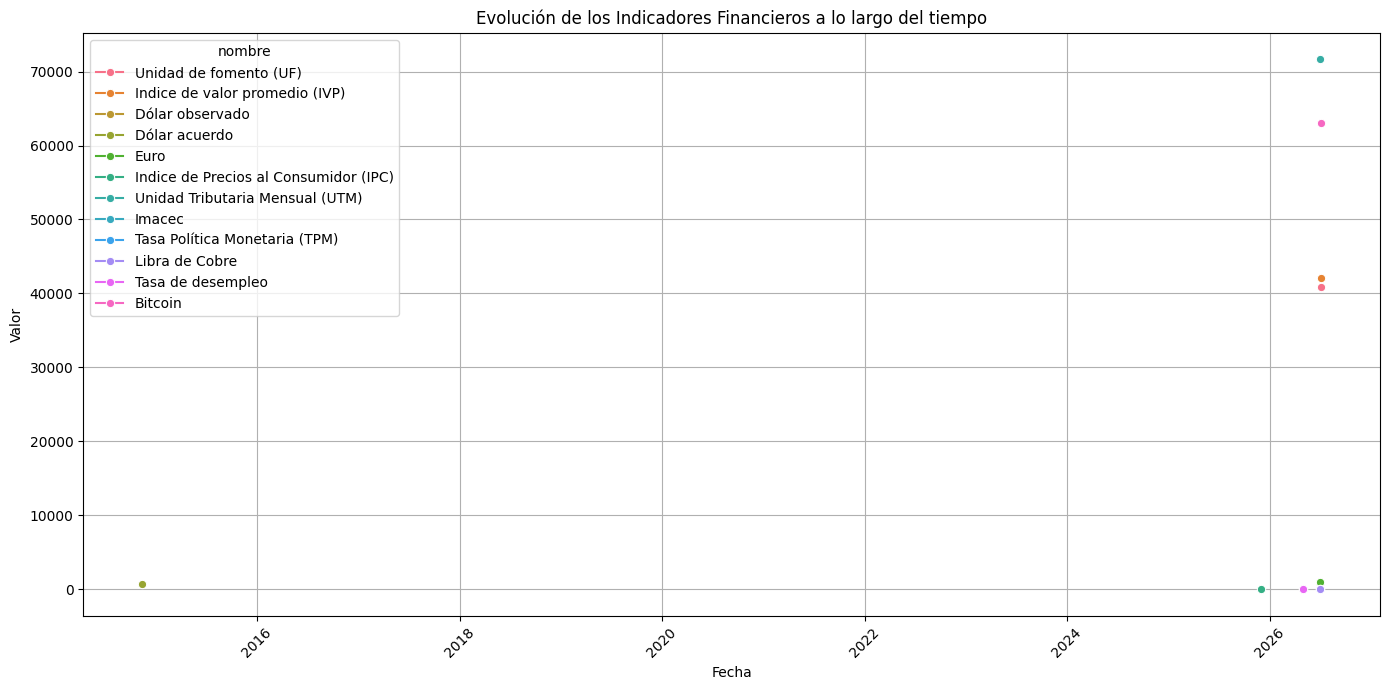

In [10]:
print("\n--- Estadísticas Descriptivas de df_api (columna 'valor') ---")
display(df_api['valor'].describe())

print("\n--- Evolución temporal de los valores de los indicadores en df_api ---")
plt.figure(figsize=(14, 7))
sns.lineplot(x='fecha', y='valor', hue='nombre', data=df_api, marker='o')
plt.title('Evolución de los Indicadores Financieros a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Construcción de un Dashboard con Plotly Dash

In [11]:
# Instalar Dash, Plotly y pyngrok para exponer el dashboard
!pip install dash plotly pyngrok --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 77.2 MB/s eta 0:00:00


In [12]:
import dash
from dash import dcc
from dash import html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd
from pyngrok import ngrok
import os
from google.colab import userdata

app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Dashboard de Análisis de Ventas de Asientos de Coche", style={'textAlign': 'center'}),

    html.Div([
        html.Label("Seleccionar ubicación del estante (ShelveLoc):"),
        dcc.Dropdown(
            id='shelveloc-dropdown',
            options=[{'label': i, 'value': i} for i in df_final['ShelveLoc'].unique()],
            value='Medium',
            multi=False
        )
    ], style={'width': '30%', 'display': 'inline-block', 'padding': '20px'}),

    dcc.Graph(id='sales-histogram'),
    dcc.Graph(id='avg-sales-by-shelveloc')
])

@app.callback(
    Output('sales-histogram', 'figure'),
    Input('shelveloc-dropdown', 'value')
)
def update_histogram(selected_shelveloc):
    filtered_df = df_final[df_final['ShelveLoc'] == selected_shelveloc]
    fig = px.histogram(filtered_df, x='Sales', nbins=20, title=f'Distribución de Ventas para ShelveLoc: {selected_shelveloc}')
    return fig

@app.callback(
    Output('avg-sales-by-shelveloc', 'figure'),
    Input('shelveloc-dropdown', 'value')
)
def update_avg_sales_bar_chart(selected_shelveloc):
    avg_sales = df_final.groupby('ShelveLoc')['Sales'].mean().reset_index()
    fig = px.bar(avg_sales, x='ShelveLoc', y='Sales', title='Ventas Promedio por Ubicación del Estante (ShelveLoc)')
    fig.update_layout(xaxis_title='Ubicación del Estante', yaxis_title='Ventas Promedio')
    return fig

port = 8050

ngrok_auth_token = userdata.get('NGROK_AUTH_TOKEN')

if ngrok_auth_token:
    ngrok.set_auth_token(ngrok_auth_token)
    print("Token de ngrok configurado desde los secretos de Colab.")
else:
    print("Advertencia: El token de autenticación de ngrok no se encontró en los secretos de Colab. El túnel no se iniciará.")
    print("Por favor, añade tu token de ngrok bajo el nombre 'NGROK_AUTH_TOKEN' en el panel de secretos de Colab (icono de llave 🔑).")

Token de ngrok configurado desde los secretos de Colab.


In [24]:
import threading
import time

def run_dash_app():
    app.run(port=port, debug=True, use_reloader=False)

if ngrok_auth_token:
    thread = threading.Thread(target=run_dash_app)
    thread.daemon = True
    thread.start()

    time.sleep(5)

    public_url = ngrok.connect(addr=port, proto='http')
    print(f"Dash App URL: {public_url}")

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on


Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.


Dash App URL: NgrokTunnel: "https://mama-unrelated-barman.ngrok-free.dev" -> "http://localhost:8050"


In [23]:
from pyngrok import ngrok

print("Deteniendo todos los túneles ngrok...")
ngrok.kill()
print("Todos los túneles ngrok han sido detenidos.")

Deteniendo todos los túneles ngrok...
Todos los túneles ngrok han sido detenidos.


## 6. Creación de Modelos Supervisados para Predicción de Ventas

El objetivo es construir dos modelos de clasificación supervisados que puedan predecir si una tienda tendrá ventas 'altas' o 'bajas'. Para ello, primero necesitamos definir estas categorías y preparar los datos.

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Seleccionar características (X) y variable objetivo (y)
# Excluir ''Sales' para evitar fuga de datos, y 'HighSales' porque es nuestro target
features = df_final.drop(columns=['Sales', 'HighSales'])
target = df_final['HighSales']

# 2. Codificación One-Hot para variables categóricas en las características
features = pd.get_dummies(features, columns=['ShelveLoc', 'Urban', 'US'], drop_first=True)

print("Dimensiones del conjunto de características (X) después de la codificación:", features.shape)
print("Dimensiones de la variable objetivo (y):", target.shape)

# 3. Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, stratify=target)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
print(f"Distribución de la variable objetivo en entrenamiento:\n{y_train.value_counts(normalize=True)}")
print(f"Distribución de la variable objetivo en prueba:\n{y_test.value_counts(normalize=True)}")

print("--- Datos listos para el entrenamiento de modelos ---")

Dimensiones del conjunto de características (X) después de la codificación: (400, 11)
Dimensiones de la variable objetivo (y): (400,)
Tamaño del conjunto de entrenamiento (X_train): (280, 11)
Tamaño del conjunto de prueba (X_test): (120, 11)
Distribución de la variable objetivo en entrenamiento:
HighSales
0    0.589286
1    0.410714
Name: proportion, dtype: float64
Distribución de la variable objetivo en prueba:
HighSales
0    0.591667
1    0.408333
Name: proportion, dtype: float64
--- Datos listos para el entrenamiento de modelos ---


### 6.2 Optimización de Hiperparámetros con `GridSearchCV`

Ahora, utilizaremos `GridSearchCV` para encontrar la mejor combinación de hiperparámetros para la Regresión Logística y el Random Forest Classifier. Esto nos permitirá mejorar el rendimiento de los modelos.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings para una salida más limpia

print("--- Optimización de Hiperparámetros con GridSearchCV ---")

# 1. Optimización para Regresión Logística
print("\n--- Optimizando Regresión Logística ---")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] # 'liblinear' para L1/L2, 'lbfgs' para L2
}

grid_search_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

best_lr_model = grid_search_lr.best_estimator_
print(f"Mejores hiperparámetros para Regresión Logística: {grid_search_lr.best_params_}")
print(f"Mejor score (Accuracy) en entrenamiento para Regresión Logística: {grid_search_lr.best_score_:.2f}")

y_pred_best_lr = best_lr_model.predict(X_test)

print("Métricas del Modelo Optimizado (Regresión Logística) en el conjunto de prueba:")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_best_lr):.2f}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_best_lr):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_best_lr):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_lr):.2f}")


# 2. Optimización para Random Forest Classifier
print("\n--- Optimizando Random Forest Classifier ---")
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_
print(f"Mejores hiperparámetros para Random Forest Classifier: {grid_search_rf.best_params_}")
print(f"Mejor score (Accuracy) en entrenamiento para Random Forest Classifier: {grid_search_rf.best_score_:.2f}")

y_pred_best_rf = best_rf_model.predict(X_test)

print("Métricas del Modelo Optimizado (Random Forest Classifier) en el conjunto de prueba:")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_best_rf):.2f}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred_best_rf):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_best_rf):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best_rf):.2f}")

print("--- Optimización de hiperparámetros completada ---")

--- Optimización de Hiperparámetros con GridSearchCV ---

--- Optimizando Regresión Logística ---
Mejores hiperparámetros para Regresión Logística: {'C': 10, 'solver': 'lbfgs'}
Mejor score (Accuracy) en entrenamiento para Regresión Logística: 0.80
Métricas del Modelo Optimizado (Regresión Logística) en el conjunto de prueba:
Exactitud (Accuracy): 0.82
Precisión (Precision): 0.83
Recall: 0.71
F1-Score: 0.77

--- Optimizando Random Forest Classifier ---
Mejores hiperparámetros para Random Forest Classifier: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Mejor score (Accuracy) en entrenamiento para Random Forest Classifier: 0.80
Métricas del Modelo Optimizado (Random Forest Classifier) en el conjunto de prueba:
Exactitud (Accuracy): 0.82
Precisión (Precision): 0.85
Recall: 0.67
F1-Score: 0.75
--- Optimización de hiperparámetros completada ---


### 6.3 Resumen y Comparación de Modelos Optimizados

A continuación, se presenta una tabla resumen con las métricas de rendimiento para los modelos de Regresión Logística y Random Forest después de la optimización con `GridSearchCV`.

In [ ]:
import pandas as pd

# Crear un DataFrame para comparar los resultados
results = {
    'Modelo': ['Regresión Logística Optimizada', 'Random Forest Optimizada'],
    'Exactitud (Accuracy)': [accuracy_score(y_test, y_pred_best_lr), accuracy_score(y_test, y_pred_best_rf)],
    'Precisión (Precision)': [precision_score(y_test, y_pred_best_lr), precision_score(y_test, y_pred_best_rf)],
    'Recall': [recall_score(y_test, y_pred_best_lr), recall_score(y_test, y_pred_best_rf)],
    'F1-Score': [f1_score(y_test, y_pred_best_lr), f1_score(y_test, y_pred_best_rf)],
    'Mejores Hiperparámetros': [grid_search_lr.best_params_, grid_search_rf.best_params_]
}

df_results = pd.DataFrame(results)

print("\n--- Comparación de Modelos Optimizado ---")
display(df_results.round(2))

# Determinar el mejor modelo basado en Accuracy
best_model_row = df_results.loc[df_results['Exactitud (Accuracy)'].idxmax()]
print(f"\nEl mejor modelo es el **{best_model_row['Modelo']}** con una Exactitud de {best_model_row['Exactitud (Accuracy)']:.2f} en el conjunto de prueba.")
print(f"Sus mejores hiperparámetros fueron: {best_model_row['Mejores Hiperparámetros']}")

print("--- Fin de la comparación de modelos ---")


--- Comparación de Modelos Optimizado ---


,Modelo,Exactitud (Accuracy),Precisión (Precision),Recall,F1-Score,Mejores Hiperparámetros
0,Regresión Logística Optimizada,0.82,0.83,0.71,0.77,"{'C': 10, 'solver': 'lbfgs'}"
1,Random Forest Optimizada,0.82,0.85,0.67,0.75,"{'max_depth': None, 'min_samples_split': 10, '..."



El mejor modelo es el **Regresión Logística Optimizada** con una Exactitud de 0.82 en el conjunto de prueba.
Sus mejores hiperparámetros fueron: {'C': 10, 'solver': 'lbfgs'}
--- Fin de la comparación de modelos ---


### Explicación de Métricas de Evaluación

Para evaluar el rendimiento de nuestros modelos de clasificación, utilizamos las siguientes métricas:

*   **Exactitud (Accuracy):** Representa la proporción de predicciones correctas sobre el total de predicciones. Es una métrica general que indica qué tan bien el modelo clasifica correctamente tanto las ventas altas como las bajas.

*   **Precisión (Precision):** Mide la proporción de verdaderos positivos (predicciones correctas de 'ventas altas') sobre el total de elementos clasificados como 'ventas altas'. Es importante cuando el costo de un falso positivo (predecir ventas altas cuando son bajas) es alto.

*   **Recall (Sensibilidad):** Mide la proporción de verdaderos positivos (predicciones correctas de 'ventas altas') sobre el total de elementos que realmente eran 'ventas altas'. Es crucial cuando el costo de un falso negativo (predecir ventas bajas cuando son altas) es alto, ya que nos asegura que estamos identificando la mayoría de las oportunidades de ventas altas.

*   **F1-Score:** Es la media armónica de la Precisión y el Recall. Proporciona un equilibrio entre ambas métricas, siendo especialmente útil cuando hay un desequilibrio en las clases o cuando ambos falsos positivos y falsos negativos son importantes.

### Conclusión de la Evaluación de Modelos Optimizados

Después de la optimización de hiperparámetros con `GridSearchCV`, se obtuvieron los siguientes resultados:

*   **Regresión Logística Optimizada:**
    *   **Exactitud (Accuracy):** 0.82
    *   **Precisión (Precision):** 0.83
    *   **Recall:** 0.71
    *   **F1-Score:** 0.77
    *   **Mejores Hiperparámetros:** `{'C': 10, 'solver': 'lbfgs'}`

*   **Random Forest Classifier Optimizada:**
    *   **Exactitud (Accuracy):** 0.82
    *   **Precisión (Precision):** 0.85
    *   **Recall:** 0.67
    *   **F1-Score:** 0.75
    *   **Mejores Hiperparámetros:** `{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}`

**Observaciones Clave:**

Ambos modelos logran un rendimiento idéntico en su capacidad global de clasificación, alcanzando un 82% de exactitud (Accuracy). Esto significa que, a nivel general, ambos sistemas tienen la misma tasa de acierto para la operación. Sin embargo, al analizar el comportamiento interno de las métricas para la toma de decisiones, se presentan dos escenarios estratégicos para el negocio:

* **Estrategia de certeza (Random Forest):** El modelo Random Forest ofrece una Precisión superior (0.85 vs 0.83). Esto significa que cuando el modelo etiqueta una ubicación como de "Ventas Altas", la empresa tiene un 85% de seguridad de que así será. Es la opción ideal si el objetivo comercial es minimizar el riesgo financiero, evitando invertir recursos en campañas o stock en tiendas que se predijeron exitosas pero que terminarán fracasando (minimiza los Falsos Positivos).

* **Estrategia de cobertura (Regresión Logística):** Por otro lado, la Regresión Logística demuestra un mejor desempeño en Recall (0.71 vs 0.67) y F1-Score (0.77 vs 0.75). Esta configuración es preferible si la prioridad de la empresa es expansiva y busca capturar la mayor cantidad de tiendas con alto potencial de ventas, asumiendo el riesgo de equivocarse en algunas ubicaciones a cambio de no dejar escapar oportunidades valiosas de mercado (minimiza los Falsos Negativos).